<a href="https://colab.research.google.com/github/Nazlan1990/Pertemuan4_Statistika/blob/main/nazlan_pertemuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = 'nazlan.xlsx'

dataraw = pd.read_excel(path)

print("Tabel Data Mahasiswa:")
display(dataraw)

Tabel Data Mahasiswa:


,NIM,Name,Marks in Quiz\n (Out of 100),Mid Term Results (Out of 100),Final Term Resul (Out of 100),Final Score,Grade
0,2455301146,Nazlan Fahrizal Ariel,90,85,80,84.85,A
1,120001,John Doe,85,78,90,84.44,A
2,120005,Jane Smith,92,88,94,91.38,A
3,120017,Michael Johnson,48,65,56,56.41,C
4,120018,Emily Brown,90,85,88,87.65,A
5,120022,Daniel Martinez,75,80,77,77.35,AB
6,120024,Sarah Wilson,88,70,65,74.01,B
7,120025,David Garcia,75,70,75,73.35,B
8,120027,Jessica Lee,95,91,96,94.03,A
9,120034,Matthew Davis,79,84,78,80.30,AB


In [29]:
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")

datafrq["Persentase (%)"] = (datafrq["Frekuensi"] / datafrq["Frekuensi"].sum() * 100)
datafrq["Persentase (%)"] = datafrq["Persentase (%)"].round(1)

urutan_grade = ['A', 'AB', 'B', 'BC', 'C', 'F']
datafrq = datafrq.reindex(urutan_grade)

print("\nTabel Frekuensi dan Persentase:")
display(datafrq)


Tabel Frekuensi dan Persentase:


col_0,Frekuensi,Persentase (%)
Grade,,
A,13,41.9
AB,7,22.6
B,4,12.9
BC,1,3.2
C,5,16.1
F,1,3.2


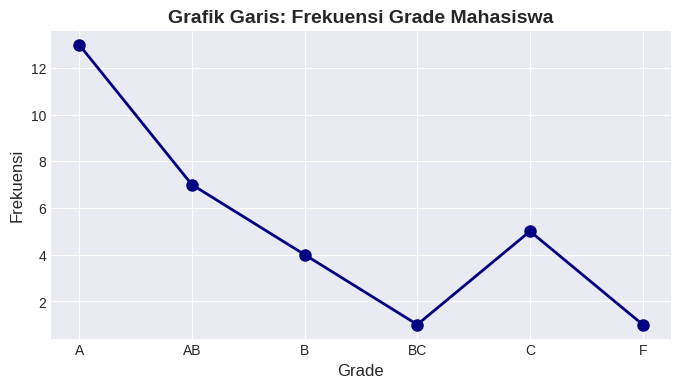

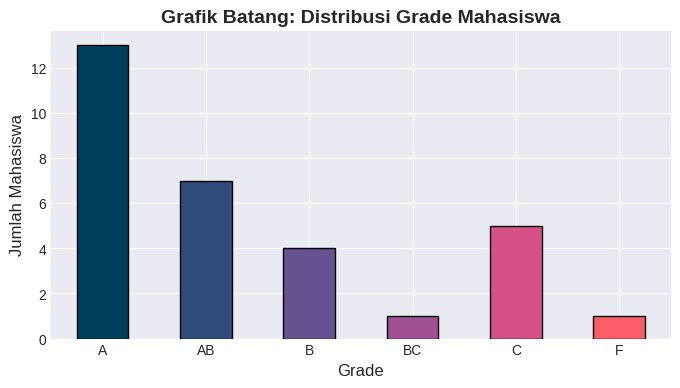

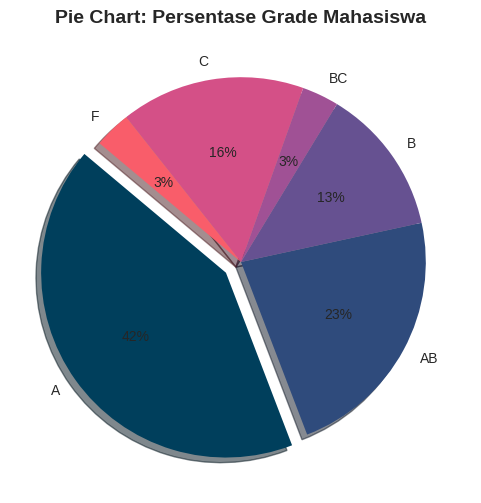

In [24]:
plt.style.use('seaborn-v0_8-darkgrid')

# 1. Grafik Garis (Line Chart)
plt.figure(figsize=(8, 4))

plt.plot(datafrq.index, datafrq['Frekuensi'], marker='o', color='navy', linewidth=2, markersize=8)
plt.title('Grafik Garis: Frekuensi Grade Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

# 2. Grafik Batang (Bar Chart)
plt.figure(figsize=(8, 4))

warna_bar_biru = ['#003f5c', '#2f4b7c', '#665191', '#a05195', '#d45087', '#f95d6a']
datafrq['Frekuensi'].plot(kind='bar', color=warna_bar_biru, edgecolor='black')
plt.title('Grafik Batang: Distribusi Grade Mahasiswa', fontsize=14, fontweight='bold')
plt.xlabel('Grade', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)
plt.xticks(rotation=0)
plt.show()

# 3. Pie Chart
plt.figure(figsize=(6, 6))
explode = (0.1, 0, 0, 0, 0, 0)
datafrq['Frekuensi'].plot(kind='pie', autopct='%1.0f%%', startangle=140,
                          explode=explode, shadow=True, colors=warna_bar_biru)
plt.title('Pie Chart: Persentase Grade Mahasiswa', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

In [34]:
dataraw.columns = ['NIM', 'Name', 'KUIS', 'UTS', 'UAS', 'Nilai', 'Grade']

dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors='coerce')
dt = dataraw["Nilai"]

stats = dt.describe().to_frame(name='Nilai')
stats.loc['Standard Error'] = dt.sem()
stats.loc['Median'] = dt.median()
stats.loc['Mode'] = dt.mode().iloc[0]
stats.loc['variance'] = dt.var()
stats.loc['range'] = dt.max() - dt.min()
stats.loc['skewness'] = dt.skew()
stats.loc['kurtosis'] = dt.kurtosis()

print("=== STATISTIKA DESKRIPTIF ===")
display(stats.round(4))

=== STATISTIKA DESKRIPTIF ===


,Nilai
count,31.0000
mean,76.4997
std,13.3306
min,46.0100
25%,68.8000
50%,79.3000
75%,86.7900
max,94.0300
Standard Error,2.3943
Median,79.3000
